# 11 — Construcción del conjunto de datos de entrenamiento

Esta notebook une las dos cadenas de preparación de datos. De la cadena de verdad de campo toma las etiquetas de lluvia fuerte de cada estación (`05-ground_truth_labels.ipynb`) y sus registros sub-horarios, que se usan en las figuras; de la cadena satelital, el inventario de imágenes utilizables (`08-goes_inventory.ipynb`) y la posición de cada estación en la grilla GOES (`10-goes_patches.ipynb`). El resultado es un índice de pares (estación, $t$) con su etiqueta, la historia de imágenes disponible y el período al que pertenece cada par, a partir del cual el cargador de datos construye las muestras del modelo.

La construcción sigue tres pasos: el cruce de las etiquetas con el inventario satelital (Sección 1), la partición temporal (Sección 2) y el tratamiento de los negativos (Sección 3).

**Output**

|Archivo|Descripción|
|-|-|
|`indice_completo.parquet`|Pares del conjunto con etiqueta, `L_max`, período, satélite, origen y ruta de la imagen de $t$, y píxel de la estación|
|`img-ejemplo_cruce_*.png`|Figuras de los ejemplos del cruce con el inventario|

In [1]:
import sys, pathlib
_raiz = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / ".gitignore").exists())
sys.path.insert(0, str(_raiz))
import entorno

In [2]:
# ============================================================
# Configuración
# ============================================================
import sys
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import to_rgba
from matplotlib.patches import Patch

RUTA_BASE   = Path(r"C:\Users\diani\Documents\repositories\nowcasting-bogota")
RUTA_GT     = RUTA_BASE / "data_ingestion" / "ground_truth"
RUTA_SAT    = RUTA_BASE / "data_ingestion" / "satellite"
RUTA_CSV    = RUTA_BASE / "data" / "rainfall_subhourly"
RUTA_UMBRAL = RUTA_GT / "umbral_operativo_por_estacion.csv"
RUTA_ETIQ   = RUTA_GT / "etiquetas_ground_truth.parquet"
RUTA_INDICE = RUTA_BASE / "datasets" / "indice_completo.parquet"

sys.path.append(str(RUTA_BASE / "src"))
from paleta import PALETA, ROL, aplicar_estilo
from etiquetado import TZ, PASO_MIN, INICIO_H, FIN_H, BLOQUE_MIN, N_BLOQUES, serie_estacion
aplicar_estilo()

# --- Historia y partición ---
L_MIN, L_MAX = 2, 4                       # historias de la matriz experimental (L ∈ {2, 3, 4})
ORDEN   = ["train", "val", "test"]
CORTES  = {"val": pd.Timestamp("2024-11-15", tz=TZ), "test": pd.Timestamp("2025-01-01", tz=TZ)}
PURGA = pd.Timedelta(hours=FIN_H)       # la etiqueta de t usa registros hasta t+3h
paso    = pd.Timedelta(minutes=PASO_MIN)

def asignar_periodo(ts_utc: pd.Series) -> np.ndarray:
    """Período según los cortes, en hora local (la purga se aplica en la Sección 2)."""
    t = ts_utc.dt.tz_convert(TZ)
    return np.select([t < CORTES["val"], t < CORTES["test"]], ["train", "val"], "test")

# Umbral y registros de cada estación (para las figuras de los ejemplos)
umbrales = pd.read_csv(RUTA_UMBRAL, dtype={"codigoestacion": str}).set_index("codigoestacion")
csvs = {p.stem: p for p in RUTA_CSV.glob("*.csv")}

## Sección 1 — Cruce con el inventario satelital

Cada par (estación, $t$) utilizable de `05-ground_truth_labels.ipynb`, es decir, con etiqueta definida y sin lluvia fuerte en curso ni tormenta inminente en $t$, se asocia con las imágenes GOES que el modelo recibe como entrada. El modelo no observa solo la imagen de $t$, sino una historia de $L$ imágenes consecutivas que terminan en ella, $t - (L-1) \cdot 10$ min, …, $t$, de modo que pueda aprender de la evolución reciente de la escena y no solo de su estado. La matriz experimental compara historias de $L = 2$, 3 y 4 imágenes, y un par solo puede usarse con una historia $L$ si dispone de todas las imágenes que esta requiere. Una imagen falta cuando el archivo no existe en el registro o cuando fue excluido en el control de calidad (`07-goes_qc.ipynb`), y ninguna de las dos situaciones pudo resolverse con la reconstrucción desde L1b (`08-goes_inventory.ipynb`).

El uso de los pares difiere entre el entrenamiento y la evaluación. Cada modelo se entrena con todos los pares del conjunto de entrenamiento que disponen de su historia, de modo que aprovecha todos los ejemplos compatibles con la entrada que requiere. El menor volumen disponible al exigir una historia más larga se considera parte del costo de esa historia. La validación y la prueba, en cambio, se realizan para los tres modelos sobre el mismo conjunto de pares: aquellos que disponen de las cuatro imágenes de la historia más larga. Así, las diferencias de desempeño entre historias se atribuyen al modelo y no a la composición de los datos, y las comparaciones son pareadas, lo que permite estimar la incertidumbre de la diferencia entre modelos sobre las mismas muestras.

El índice resultante contiene, para cada par, la etiqueta, el largo de historia disponible (`L_max`), el satélite, el origen y la ruta de la imagen de $t$, y las coordenadas del píxel de la estación en la grilla GOES (`estaciones_pixels.csv`, de `10-goes_patches.ipynb`), además del período, que se asigna en la Sección 2. Las rutas de las imágenes anteriores de la historia se resuelven desde el inventario al construir cada muestra, por lo que no se almacenan en el índice.

In [3]:
# ============================================================
# Sección 1 — Cruce con el inventario satelital
# ============================================================
etiq  = pd.read_parquet(RUTA_ETIQ)
pares = (etiq.loc[etiq["etiqueta"].notna() & ~etiq["en_curso"] & ~etiq["inminente"],
                  ["codigoestacion", "timestamp", "etiqueta"]].reset_index(drop=True))

inv_full = pd.read_parquet(RUTA_SAT / "inventario_goes.parquet")
inv_full["timestamp"] = inv_full["timestamp"].dt.tz_localize("UTC")     # UTC sin zona → UTC con zona
inv = inv_full[~inv_full["excluido_qc"]].copy()

pixels = pd.read_csv(RUTA_SAT / "estaciones_pixels.csv")

for nombre, s in [("pares", pares["timestamp"]), ("inventario", inv["timestamp"])]:
    print(f"{nombre:<11}: {s.dtype}  |  tz = {s.dt.tz}")
assert str(pares["timestamp"].dt.tz) == str(inv["timestamp"].dt.tz) == "UTC"

print(f"\nPares utilizables   : {len(pares):,}")
print(f"Imágenes utilizables: {len(inv):,}  ({(inv['origen'] == 'L1b').sum()} reconstruidas desde L1b)")
print(f"Estaciones con píxel: {len(pixels)}  |  en pares: {pares['codigoestacion'].nunique()}")

pares      : datetime64[ns, UTC]  |  tz = UTC
inventario : datetime64[ns, UTC]  |  tz = UTC

Pares utilizables   : 4,062,075
Imágenes utilizables: 104,745  (82 reconstruidas desde L1b)
Estaciones con píxel: 63  |  en pares: 63


In [4]:
disponibles = pd.DatetimeIndex(inv["timestamp"])

def l_max_de(ts_utc: pd.DatetimeIndex) -> np.ndarray:
    """Imágenes consecutivas disponibles terminando en cada t (0 si falta la de t)."""
    h = np.column_stack([(ts_utc - k * paso).isin(disponibles) for k in range(L_MAX)])
    return np.cumprod(h, axis=1).sum(axis=1)

ts = pd.DatetimeIndex(pares["timestamp"].unique())
pares = pares.join(pd.Series(l_max_de(ts), index=ts, name="L_max"), on="timestamp")
pares["periodo"] = asignar_periodo(pares["timestamp"])

# Positivos disponibles según la historia exigida
pos = pares[pares["etiqueta"] == 1]
disp = pd.DataFrame({f"L≥{L}": pos[pos["L_max"] >= L].groupby("periodo").size()
                     for L in range(1, L_MAX + 1)}).reindex(ORDEN)
disp.insert(0, "positivos", pos.groupby("periodo").size().reindex(ORDEN))
print("Positivos con historia disponible:")
print(disp.to_string())
print("\nUso: train con L_max ≥ L (cada modelo); val y test con L_max = 4 (común a los tres).")

Positivos con historia disponible:
         positivos    L≥1    L≥2    L≥3    L≥4
periodo                                       
train         4490   4306   4259   4212   4165
val           1627   1559   1554   1548   1542
test         12466  12444  12420  12393  12367

Uso: train con L_max ≥ L (cada modelo); val y test con L_max = 4 (común a los tres).


In [5]:
indice = (pares[pares["L_max"] >= L_MIN]
          .merge(inv[["timestamp", "satelite", "origen", "filepath"]],
                 on="timestamp", how="left", validate="many_to_one"))

# Píxel de la estación: el código es entero en estaciones_pixels.csv y texto con ceros en las etiquetas
indice["cod_int"] = indice["codigoestacion"].astype("int64")
indice = (indice.merge(pixels[["codigoestacion", "fila", "col"]].rename(columns={"codigoestacion": "cod_int"}),
                       on="cod_int", how="left", validate="many_to_one")
                .drop(columns="cod_int"))

assert indice[["filepath", "fila", "col"]].notna().all().all(), "pares sin imagen o sin píxel"
assert not indice.duplicated(["codigoestacion", "timestamp"]).any()

indice = indice[["codigoestacion", "timestamp", "etiqueta", "L_max", "periodo",
                 "satelite", "origen", "filepath", "fila", "col"]]

print("Índice por período y satélite (todos los pares con L_max ≥ 2, antes de la purga):")
print(indice.groupby(["periodo", "satelite"])["etiqueta"]
      .agg(pares="size", positivos="sum", frac="mean")
      .assign(frac=lambda d: d["frac"].map("{:.3%}".format))
      .reindex(ORDEN, level=0).to_string())

Índice por período y satélite (todos los pares con L_max ≥ 2, antes de la purga):
                    pares  positivos    frac
periodo satelite                            
train   G16       1248368     4259.0  0.341%
val     G16        333989     1554.0  0.465%
test    G16        513173     2417.0  0.471%
        G19       1936202    10003.0  0.517%


In [6]:
pos_etiq = etiq[etiq["etiqueta"] == 1].copy()
pos_etiq["periodo"] = asignar_periodo(pos_etiq["timestamp"])

balance = pd.DataFrame({
    "etiqueta_1":      pos_etiq.groupby("periodo").size(),
    "lluvia_en_curso": pos_etiq[pos_etiq["en_curso"]].groupby("periodo").size(),
    "utilizables":     pos.groupby("periodo").size(),
    "con_L≥2":         pos[pos["L_max"] >= 2].groupby("periodo").size(),
    "con_L=4":         pos[pos["L_max"] == 4].groupby("periodo").size(),
    "cobertura_incompleta": pos_etiq[~pos_etiq["en_curso"] & ~pos_etiq["cobertura"]].groupby("periodo").size(),
}).reindex(ORDEN).fillna(0).astype(int)

balance["usados"] = np.where(balance.index == "train", balance["con_L≥2"], balance["con_L=4"])
balance["perdida_%"] = (1 - balance["usados"] / balance["etiqueta_1"]).map("{:.1%}".format)
print(balance.to_string())
print("\nusados: train = L≥2 (máximo disponible, modelo L=2); val y test = L=4 (conjunto común).")

         etiqueta_1  lluvia_en_curso  utilizables  con_L≥2  con_L=4  cobertura_incompleta  usados perdida_%
periodo                                                                                                    
train          4569               79         4490     4259     4165                    20    4259      6.8%
val            1654               27         1627     1554     1542                    60    1542      6.8%
test          12719              253        12466    12420    12367                   225   12367      2.8%

usados: train = L≥2 (máximo disponible, modelo L=2); val y test = L=4 (conjunto común).


**Resultado**. De los 4,062,075 pares utilizables, 4,031,732 disponen de al menos dos imágenes consecutivas y conforman el índice, con 18,233 positivos. El factor que más reduce la muestra es la ausencia de la imagen del propio instante $t$, mientras que cada imagen adicional de historia tiene un costo marginal pequeño: en el conjunto de entrenamiento, exigir la imagen de $t$ descarta 184 positivos, exigir además la de $t - 10$ min descarta 47, y pasar de una historia de dos a una de cuatro imágenes descarta 94 más (2.2%). El modelo con $L = 2$ se entrena así con 4,259 positivos y el modelo con $L = 4$ con 4,165. Los tres modelos se evalúan sobre 1,542 positivos en validación y 12,367 en prueba, antes de la purga de la Sección 2.

El balance completo, desde las etiquetas positivas hasta los positivos efectivamente utilizados, muestra una pérdida acumulada del 6.8% en entrenamiento, del 6.8% en validación y del 2.8% en prueba. La mayor pérdida en 2024 responde a la mayor concentración de instantes sin imagen utilizable en ese año, que persiste aun tras la reconstrucción desde L1b. Los positivos con cobertura incompleta en la ventana, que la definición de la etiqueta conserva por contener una hora observada sobre el umbral, representan el 0.4% de los positivos utilizables en entrenamiento, el 3.7% en validación y el 1.8% en prueba.

In [7]:
# Cifras citadas en el texto de la Sección 1
tr = disp.loc["train"]
assert (len(pares), len(indice), int((indice["etiqueta"] == 1).sum())) == (4_062_075, 4_031_732, 18_233)
assert tr.tolist() == [4490, 4306, 4259, 4212, 4165]
assert (disp.loc["val", "L≥4"], disp.loc["test", "L≥4"]) == (1542, 12367)
assert balance["perdida_%"].tolist() == ["6.8%", "6.8%", "2.8%"]
assert balance["cobertura_incompleta"].tolist() == [20, 60, 225]
# Verificación cruzada con 08-goes_inventory.ipynb (pérdida residual con L = 4)
assert (balance["utilizables"] - balance["con_L=4"]).tolist() == [325, 85, 99]
print("Cifras de la Sección 1 verificadas")

Cifras de la Sección 1 verificadas


### Ejemplos del cruce con el inventario

Para seguir el efecto del cruce sobre casos concretos se examinan seis episodios, elegidos de modo que cada uno ponga a prueba una parte distinta del procedimiento:

1. **Registro completo** (25 de abril de 2025, estación 2120000128): el episodio de `05-ground_truth_labels.ipynb`, sin instantes faltantes.
2. **Reconstrucción parcial desde L1b** (20 de marzo de 2024, estación 2120000170): la estación con más positivos de historia incompleta en el bloque faltante de ese día.
3. **Instante aislado excluido en el control de calidad** (23 de octubre de 2025, estación 0021205012): el instante excluido del conjunto de prueba que afecta a más pares positivos.
4. **Corte breve de registros de la estación** (20 de noviembre de 2024, estación 2120000117): el criterio de cobertura con el registro satelital completo.
5. **Corte de registros coincidente con un bloque satelital** (15 de noviembre de 2024, estación 2120000124): ambos faltantes en la misma tarde.
6. **Corte de registros antes de $t$** (30 de diciembre de 2024, estación 0021201980): exclusiones que no pueden verificarse.

Para cada instante $t$ se muestran, en hora local, la intensidad horaria de la estación con la posición de sus registros, el estado de la imagen GOES de $t$, la etiqueta asignada y el destino del par en el índice, que resume si dispone de la historia completa de cuatro imágenes, de una historia parcial o de ninguna historia utilizable. Bajo cada figura se listan los tramos consecutivos de cada estado, que son la base de la descripción de cada episodio.

In [8]:
ancho = paso
estado_img = pd.Series(np.where(inv_full["excluido_qc"], "excluida QC", inv_full["origen"]),
                       index=inv_full["timestamp"])

COL_IMG  = {"CMIP": PALETA["wwu-blue"], "L1b": PALETA["wwu-green"],
            "excluida QC": to_rgba(PALETA["wi-grey"], 0.7), "sin archivo": to_rgba(PALETA["wi-grey"], 0.35)}
COL_ETQ  = {"positivo": ROL["positivo"], "negativo": to_rgba(PALETA["wi-grey"], 0.35),
            "lluvia en curso": to_rgba(PALETA["wwu-black"], 0.90),
            "tormenta inminente": to_rgba(PALETA["wwu-black"], 0.75), "sin cobertura": "white"}
COL_DEST = {"L_max = 4": PALETA["wi-purple"],
            "L_max = 2–3": to_rgba(PALETA["wi-purple"], 0.55),
            "fuera: sin imagen (L_max < 2)": to_rgba(PALETA["wi-grey"], 0.6),
            "fuera: sin etiqueta utilizable": "white"}

def franja(ax, x, estados, colores, titulo):
    ax.bar(x, 1, width=ancho, align="edge", color=[colores[s] for s in estados],
           edgecolor="white", linewidth=0.3)
    ax.set_ylim(0, 1); ax.set_yticks([])
    ax.set_ylabel(titulo, rotation=0, ha="right", va="center", fontsize=9)
    presentes = [k for k in colores if k in set(estados)]
    ax.legend(handles=[Patch(facecolor=colores[k], edgecolor=ROL["linea_ref"], lw=0.5, label=k)
                       for k in presentes],
              fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)

def tramos(estados, x):
    """Tramos consecutivos de un mismo estado, con su inicio y fin en hora local."""
    d = pd.DataFrame({"estado": estados, "t": x})
    d["g"] = (d["estado"] != d["estado"].shift()).cumsum()
    return (d.groupby("g").agg(estado=("estado", "first"), desde=("t", "min"),
                               hasta=("t", "max"), n=("t", "size"))
             .assign(desde=lambda r: r["desde"].dt.strftime("%H:%M"),
                     hasta=lambda r: r["hasta"].dt.strftime("%H:%M"))
             .reset_index(drop=True))

def figura_cruce(cod, t_ini, t_fin, archivo=None):
    """Figura del cruce para una estación entre t_ini y t_fin (hora local sin zona).
    Devuelve el detalle por instante: imagen, etiqueta, L_max y destino."""
    g_loc = pd.date_range(t_ini, t_fin, freq=f"{PASO_MIN}min", tz=TZ)
    g_utc = g_loc.tz_convert("UTC")
    x     = g_loc.tz_localize(None)

    img = estado_img.reindex(g_utc).fillna("sin archivo").values
    e   = etiq[etiq["codigoestacion"] == cod].set_index("timestamp").reindex(g_utc)
    etq = np.select([e["en_curso"].fillna(False).astype(bool),
                     e["inminente"].fillna(False).astype(bool),
                     e["etiqueta"] == 1, e["etiqueta"] == 0],
                    ["lluvia en curso", "tormenta inminente", "positivo", "negativo"],
                    "sin cobertura")
    lm   = l_max_de(g_utc)
    util = np.isin(etq, ["positivo", "negativo"])
    dest = np.select([util & (lm == 4), util & (lm >= 2), util],
                     ["L_max = 4", "L_max = 2–3", "fuera: sin imagen (L_max < 2)"],
                     "fuera: sin etiqueta utilizable")

    s = serie_estacion(csvs[cod])["intensidad_mm_h"]
    s.index = s.index.tz_convert(TZ).tz_localize(None)
    s = s.loc[pd.Timestamp(t_ini):pd.Timestamp(t_fin)]
    reg = s.index
    salto = s.index.to_series().diff() > pd.Timedelta("20min")        # cortes: la línea no los une
    s = pd.concat([s, pd.Series(np.nan, index=s.index[salto.values] - pd.Timedelta("1min"))]).sort_index()
    umb = float(umbrales.loc[cod, "umbral_mm_h"])
    y_max = max(s.max() if s.notna().any() else 0.0, umb) * 1.1

    fig, axes = plt.subplots(4, 1, figsize=(13, 7.5), sharex=True,
                             gridspec_kw={"height_ratios": [2.2, 0.6, 0.6, 0.6]})
    ax = axes[0]
    ax.plot(s.index, s.values, color=ROL["serie"], lw=1.4, label="Intensidad horaria")
    ax.axhline(umb, color=ROL["linea_ref"], ls="--", lw=1, label=f"Umbral ({umb:.1f} mm/h)")
    ax.fill_between(s.index, umb, s.values, where=(s.values >= umb),
                    color=ROL["umbral"], alpha=0.25, lw=0)
    ax.plot(reg, np.full(len(reg), -0.05 * y_max), "|", ms=6, mew=0.6,
            color=ROL["linea_ref"], label="Registro de la estación")
    ax.set_ylim(-0.1 * y_max, y_max)
    ax.set_ylabel("mm/h")
    ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)

    franja(axes[1], x, img,  COL_IMG,  "Imagen en t")
    franja(axes[2], x, etq,  COL_ETQ,  "Etiqueta en t")
    franja(axes[3], x, dest, COL_DEST, "Destino del par")

    perdidos = (etq == "positivo") & (lm < 2)
    if perdidos.any():
        axes[3].scatter(x[perdidos] + ancho / 2, np.full(perdidos.sum(), 0.5),
                        marker="x", color="black", s=18, lw=1, zorder=3, label="positivo perdido")

    axes[-1].set_xlim(x[0], x[-1] + ancho)
    axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=1))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    axes[-1].set_xlabel(f"Hora local, {x[0]:%d-%m-%Y}")
    fig.suptitle(f"Cruce de etiquetas e imágenes — estación {cod}", fontsize=11)
    plt.tight_layout()
    if archivo:
        fig.savefig(archivo, dpi=200, bbox_inches="tight")
    plt.show()

    for nombre, estados in [("Imagen en t", img), ("Etiqueta en t", etq), ("Destino del par", dest)]:
        print(f"{nombre}\n{tramos(estados, x).to_string(index=False)}\n")
    print(pd.crosstab(pd.Series(etq, name="etiqueta"), pd.Series(dest, name="destino")).to_string())
    return pd.DataFrame({"imagen": img, "etiqueta": etq, "L_max": lm, "destino": dest}, index=x)

def registros_por_bloque(cod, t_ini, t_fin):
    """Registros de la estación en cada bloque de 30 min de la ventana, para los pares con cobertura incompleta."""
    e = etiq[etiq["codigoestacion"] == cod].copy()
    e["t_local"] = e["timestamp"].dt.tz_convert(TZ).dt.tz_localize(None)
    e = e[(e["t_local"] >= pd.Timestamp(t_ini)) & (e["t_local"] <= pd.Timestamp(t_fin)) & ~e["cobertura"]]
    reg = serie_estacion(csvs[cod]).index
    filas = []
    for t, t_loc, et in e[["timestamp", "t_local", "etiqueta"]].itertuples(index=False):
        bordes = [t + pd.Timedelta(hours=INICIO_H) + pd.Timedelta(minutes=BLOQUE_MIN * k)
                  for k in range(N_BLOQUES + 1)]
        filas.append({"t_local": f"{t_loc:%H:%M}",
                      **{f"bloque_{k + 1}": int(((reg > a) & (reg <= b)).sum())
                         for k, (a, b) in enumerate(zip(bordes[:-1], bordes[1:]))},
                      "etiqueta": "indefinida" if np.isnan(et) else int(et)})
    tabla = pd.DataFrame(filas)
    if len(tabla):
        assert (tabla.filter(like="bloque_") == 0).any(axis=1).all()
    return tabla

#### 1. Registro completo

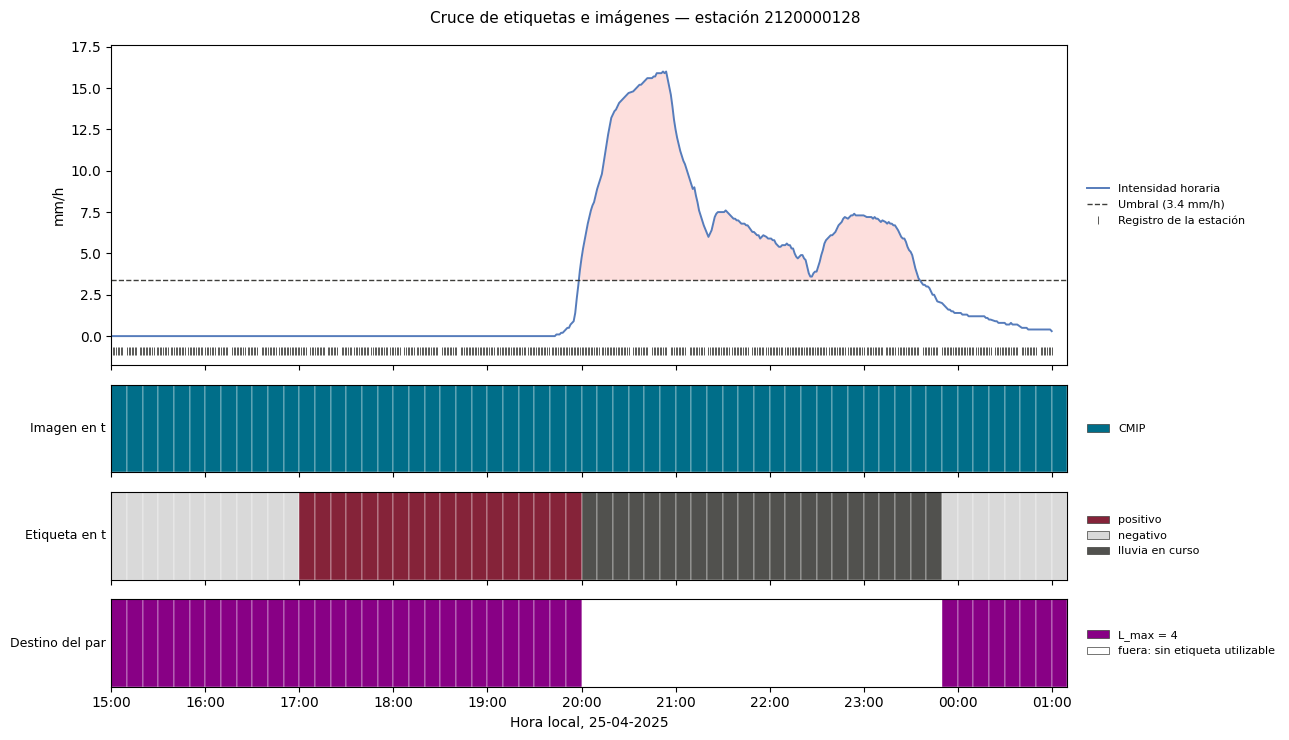

Imagen en t
estado desde hasta  n
  CMIP 15:00 01:00 61

Etiqueta en t
         estado desde hasta  n
       negativo 15:00 16:50 12
       positivo 17:00 19:50 18
lluvia en curso 20:00 23:40 23
       negativo 23:50 01:00  8

Destino del par
                        estado desde hasta  n
                     L_max = 4 15:00 19:50 30
fuera: sin etiqueta utilizable 20:00 23:40 23
                     L_max = 4 23:50 01:00  8

destino          L_max = 4  fuera: sin etiqueta utilizable
etiqueta                                                  
lluvia en curso          0                              23
negativo                20                               0
positivo                18                               0


In [9]:
det_2025 = figura_cruce("2120000128", "2025-04-25 15:00", "2025-04-26 01:00",
                        archivo="img-ejemplo_cruce_2025.png")

En el episodio del 25 de abril de 2025 el registro satelital está completo y todas las imágenes provienen del producto CMIP, de modo que el cruce no descarta ningún par por falta de imagen. Los 18 positivos, tomados entre las 17:00 y las 19:50, y los 20 negativos anteriores y posteriores a la tormenta disponen de la historia completa de cuatro imágenes y entran al índice. Los 23 pares con lluvia fuerte en curso, entre las 20:00 y las 23:40, quedan fuera por su etiqueta y no por el cruce.

#### 2. Reconstrucción parcial desde L1b

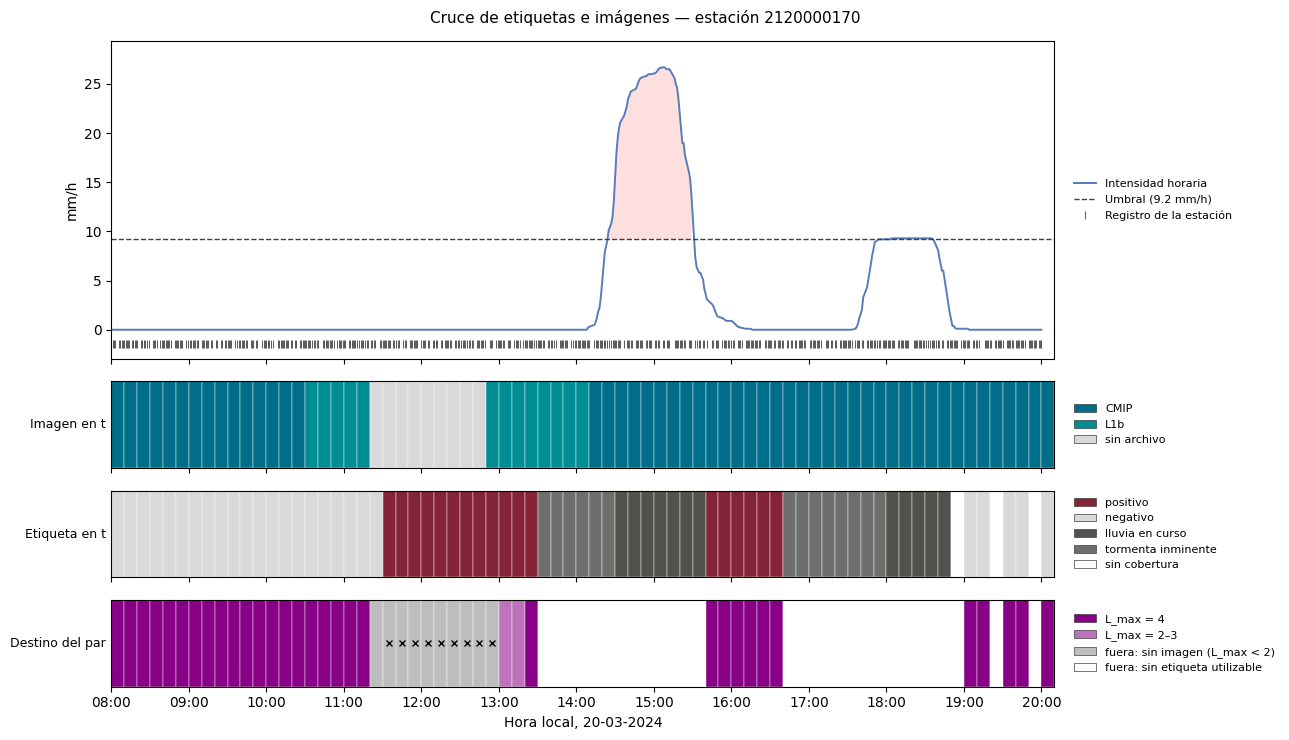

Imagen en t
     estado desde hasta  n
       CMIP 08:00 10:20 15
        L1b 10:30 11:10  5
sin archivo 11:20 12:40  9
        L1b 12:50 14:00  8
       CMIP 14:10 20:00 36

Etiqueta en t
            estado desde hasta  n
          negativo 08:00 11:20 21
          positivo 11:30 13:20 12
tormenta inminente 13:30 14:20  6
   lluvia en curso 14:30 15:30  7
          positivo 15:40 16:30  6
tormenta inminente 16:40 17:50  8
   lluvia en curso 18:00 18:40  5
     sin cobertura 18:50 18:50  1
          negativo 19:00 19:10  2
     sin cobertura 19:20 19:20  1
          negativo 19:30 19:40  2
     sin cobertura 19:50 19:50  1
          negativo 20:00 20:00  1

Destino del par
                        estado desde hasta  n
                     L_max = 4 08:00 11:10 20
 fuera: sin imagen (L_max < 2) 11:20 12:50 10
                   L_max = 2–3 13:00 13:10  2
                     L_max = 4 13:20 13:20  1
fuera: sin etiqueta utilizable 13:30 15:30 13
                     L_max = 4 15:40 16:30

In [10]:
det_2024 = figura_cruce("2120000170", "2024-03-20 08:00", "2024-03-20 20:00",
                        archivo="img-ejemplo_cruce_2024.png")

El 20 de marzo de 2024 la estación 2120000170, con un umbral de 9.2 mm/h, registra dos episodios de lluvia fuerte. El primero mantiene la acumulación horaria sobre el umbral entre las 14:30 y las 15:30, hora local; el segundo apenas lo alcanza entre las 18:00 y las 18:40. El registro satelital de la mañana contiene imágenes reconstruidas desde L1b entre las 10:30 y las 11:10 y entre las 12:50 y las 14:00, y un tramo sin imagen utilizable entre las 11:20 y las 12:40.

La etiqueta se construye de la misma forma en los dos episodios. Las imágenes de 11:30 a 13:20 son positivas por el primero, y las de 15:40 a 16:30, por el segundo. Las de 13:30 a 14:20 y de 16:40 a 17:50 se excluyen por tormenta inminente, dado que la lluvia fuerte llega a la estación pero ninguna hora completa de su ventana alcanza el umbral, y las de 14:30 a 15:30 y de 18:00 a 18:40 se excluyen por lluvia en curso.

El cruce con el inventario descarta 9 de los 18 positivos, los tomados entre las 11:30 y las 12:50. Los ocho primeros no tienen imagen en $t$, y el de las 12:50, que sí la tiene gracias a la reconstrucción, no alcanza la historia mínima de dos imágenes que exigen todos los modelos de la matriz experimental. Los positivos de las 13:00 y las 13:10 entran al índice con una historia parcial de dos y tres imágenes, y se usan solo en el entrenamiento de los modelos con historias más cortas; a partir de las 13:20 la historia está completa. Sin la reconstrucción desde L1b, el tramo sin imagen se extendería de las 10:30 a las 14:00 y el primer episodio perdería sus doce positivos. Los positivos del segundo episodio, en cambio, no dependen del cruce, dado que a esa hora el registro está completo.

#### 3. Instante aislado excluido en el control de calidad

Instante excluido 23-10-2025 17:40 (hora local): 9 estaciones, 31 pares positivos afectados



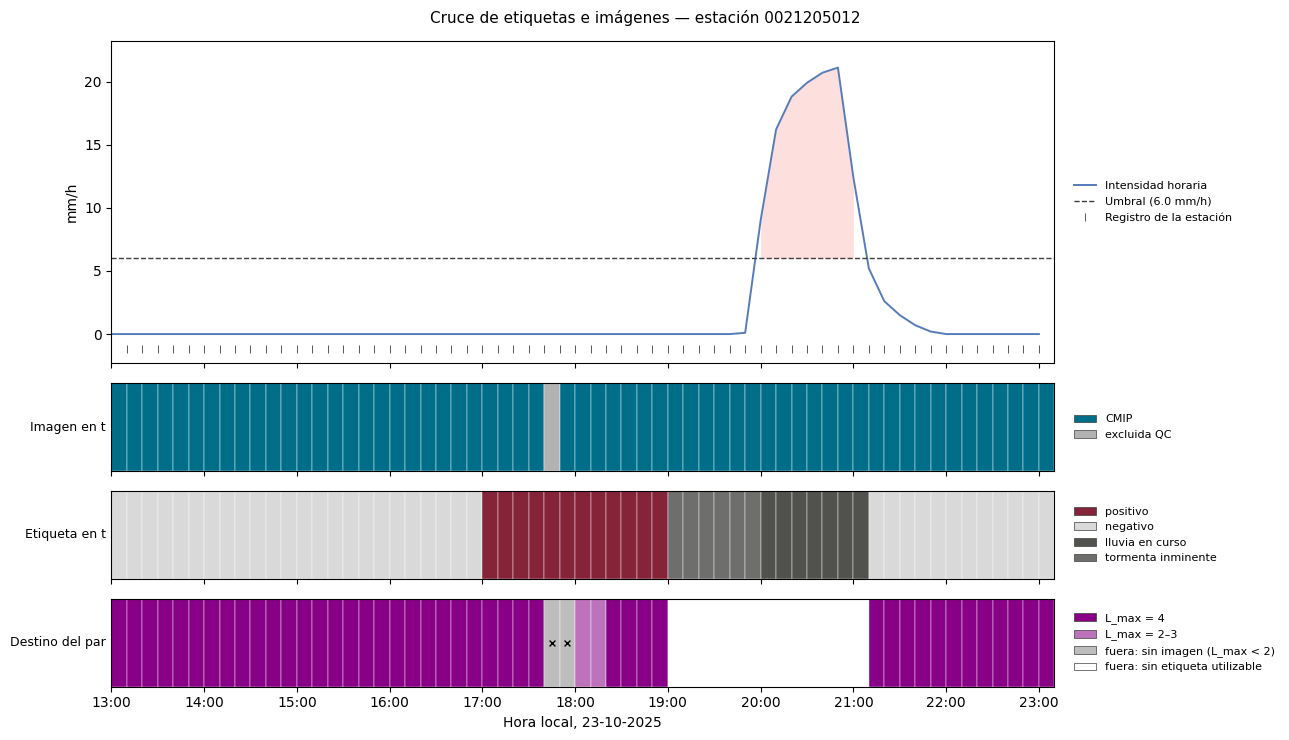

Imagen en t
     estado desde hasta  n
       CMIP 13:00 17:30 28
excluida QC 17:40 17:40  1
       CMIP 17:50 23:00 32

Etiqueta en t
            estado desde hasta  n
          negativo 13:00 16:50 24
          positivo 17:00 18:50 12
tormenta inminente 19:00 19:50  6
   lluvia en curso 20:00 21:00  7
          negativo 21:10 23:00 12

Destino del par
                        estado desde hasta  n
                     L_max = 4 13:00 17:30 28
 fuera: sin imagen (L_max < 2) 17:40 17:50  2
                   L_max = 2–3 18:00 18:10  2
                     L_max = 4 18:20 18:50  4
fuera: sin etiqueta utilizable 19:00 21:00 13
                     L_max = 4 21:10 23:00 12

destino             L_max = 2–3  L_max = 4  fuera: sin etiqueta utilizable  fuera: sin imagen (L_max < 2)
etiqueta                                                                                                 
lluvia en curso               0          0                               7                              0
neg

In [11]:
X_QC  = pd.Timestamp("2025-10-23 22:40", tz="UTC")
x_loc = X_QC.tz_convert(TZ).tz_localize(None)
af = pos[(pos["timestamp"] >= X_QC) & (pos["timestamp"] <= X_QC + (L_MAX - 1) * paso)]
print(f"Instante excluido {x_loc:%d-%m-%Y %H:%M} (hora local): "
      f"{af['codigoestacion'].nunique()} estaciones, {len(af)} pares positivos afectados\n")

det_qc = figura_cruce("0021205012", "2025-10-23 13:00", "2025-10-23 23:00",
                      archivo="img-ejemplo_cruce_qc.png")
print(f"\nDetalle en torno al instante excluido:")
print(det_qc.loc[x_loc - paso: x_loc + L_MAX * paso].to_string())

El instante excluido con mayor efecto sobre los positivos del conjunto de prueba es el de las 22:40 UTC del 23 de octubre de 2025 (17:40, hora local), que afecta a pares positivos de nueve estaciones durante la misma tarde. En la estación 0021205012, cuyo umbral es de 6.0 mm/h, la acumulación horaria supera el umbral entre las 20:00 y las 21:00, en un aguacero breve precedido por una tarde sin lluvia. Las imágenes tomadas entre las 17:00 y las 18:50 reciben etiqueta positiva. Las de 19:00 a 19:50 se excluyen por tormenta inminente, dado que su ventana comienza cuando la hora de lluvia fuerte ya se completó, y las de 20:00 a 21:00 se excluyen por lluvia en curso. La estación transmite cada diez minutos sin interrupciones, de modo que ninguna etiqueta queda indefinida.

La imagen excluida cae en medio de la secuencia de positivos, algo más de dos horas antes del inicio de la lluvia fuerte, en plena fase precursora. El par de las 17:40 queda fuera del índice por carecer de imagen de entrada, y el de las 17:50, que sí la tiene, porque sin la imagen anterior no reúne la historia mínima de dos imágenes que exigen todos los modelos de la matriz experimental. Los de las 18:00 y las 18:10 entran al índice con historias de dos y tres imágenes, y a partir de las 18:20 la historia vuelve a estar completa. Una sola imagen faltante afecta así a los cuatro pares que la requieren en su historia, sin alterar la etiqueta de ninguno. Como la evaluación exige la historia completa, los cuatro quedan fuera del conjunto de prueba, que conserva 8 de los 12 positivos del episodio.

#### 4. Corte breve de registros de la estación

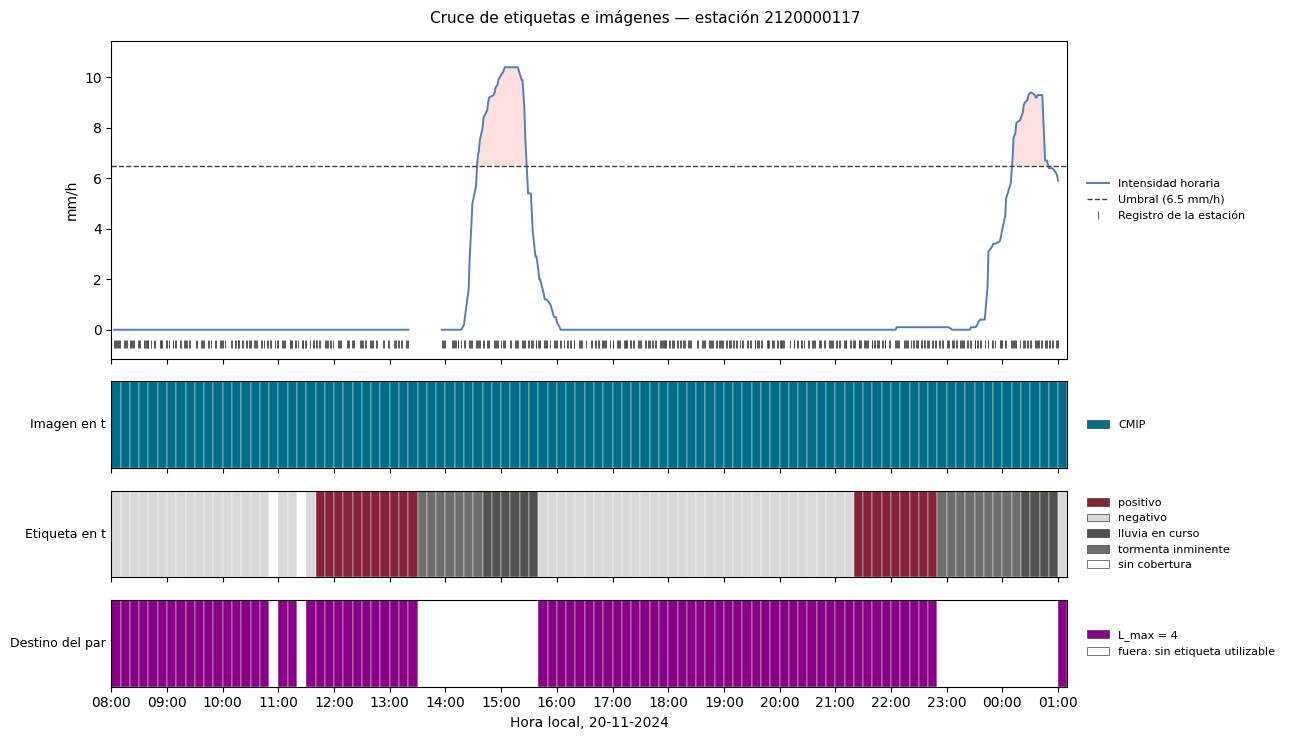

Imagen en t
estado desde hasta   n
  CMIP 08:00 01:00 103

Etiqueta en t
            estado desde hasta  n
          negativo 08:00 10:40 17
     sin cobertura 10:50 10:50  1
          negativo 11:00 11:10  2
     sin cobertura 11:20 11:20  1
          negativo 11:30 11:30  1
          positivo 11:40 13:20 11
tormenta inminente 13:30 14:30  7
   lluvia en curso 14:40 15:30  6
          negativo 15:40 21:10 34
          positivo 21:20 22:40  9
tormenta inminente 22:50 00:10  9
   lluvia en curso 00:20 00:50  4
          negativo 01:00 01:00  1

Destino del par
                        estado desde hasta  n
                     L_max = 4 08:00 10:40 17
fuera: sin etiqueta utilizable 10:50 10:50  1
                     L_max = 4 11:00 11:10  2
fuera: sin etiqueta utilizable 11:20 11:20  1
                     L_max = 4 11:30 13:20 12
fuera: sin etiqueta utilizable 13:30 15:30 13
                     L_max = 4 15:40 22:40 43
fuera: sin etiqueta utilizable 22:50 00:50 13
                    

In [12]:
det_cob = figura_cruce("2120000117", "2024-11-20 08:00", "2024-11-21 01:00",
                       archivo="img-ejemplo_cruce_cobertura.png")
print("\nRegistros por bloque de la ventana en los pares con cobertura incompleta:")
print(registros_por_bloque("2120000117", "2024-11-20 08:00", "2024-11-21 01:00").to_string(index=False))

El episodio del 20 de noviembre de 2024 en la estación 2120000117, cuya etiqueta se describe en `05-ground_truth_labels.ipynb`, sigue el criterio de cobertura hasta el índice. El registro satelital está completo y todas las imágenes provienen del producto CMIP, de modo que el destino de cada par depende solo de su etiqueta. Las imágenes de 10:50 y 11:20, con etiqueta indefinida, quedan fuera del índice, mientras que las de 11:50 y 12:20, positivas pese al corte de registros de la estación, entran con la historia completa de cuatro imágenes junto con el resto de los positivos del primer episodio, de 11:40 a 13:20. Los 20 positivos del día disponen de la historia completa y, dado que el episodio pertenece al período de validación, forman parte del conjunto común sobre el que se evalúan los tres modelos.

Las cuatro imágenes afectadas muestran las dos ramas del criterio. Las de 10:50 y 11:20 quedan con etiqueta indefinida, puesto que su tramo evaluado termina antes del inicio de la lluvia fuerte y el corte impide descartar que haya ocurrido sin registrarse. Las de 11:50 y 12:20, en cambio, contienen en su ventana horas sobre el umbral registradas después del corte, y reciben etiqueta positiva con certeza. La secuencia de positivos del primer episodio queda así continua entre las 11:40 y las 13:20, seguida por la tormenta inminente de 13:30 a 14:30. El segundo episodio produce positivos de 21:20 a 22:40 y tormenta inminente de 22:50 a 00:10.

#### 5. Corte de registros coincidente con un bloque satelital

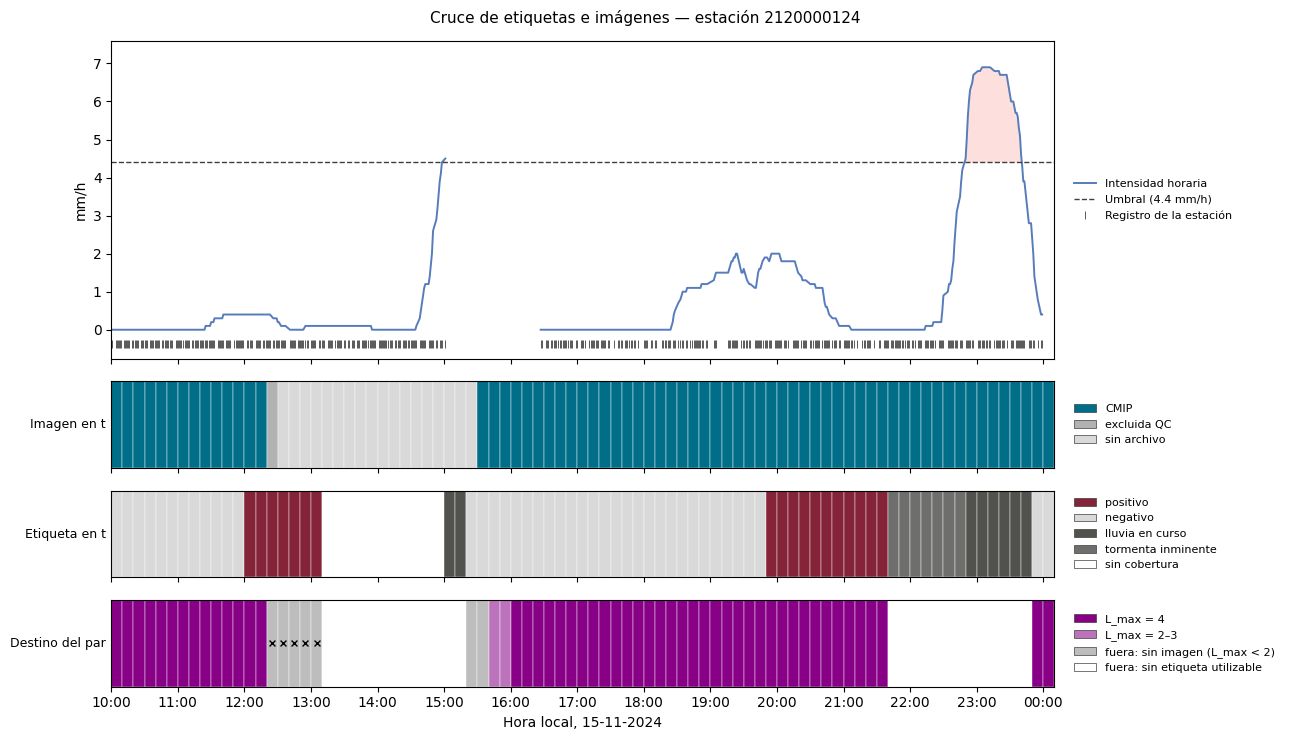

Imagen en t
     estado desde hasta  n
       CMIP 10:00 12:10 14
excluida QC 12:20 12:20  1
sin archivo 12:30 15:20 18
       CMIP 15:30 00:00 52

Etiqueta en t
            estado desde hasta  n
          negativo 10:00 11:50 12
          positivo 12:00 13:00  7
     sin cobertura 13:10 14:50 11
   lluvia en curso 15:00 15:10  2
          negativo 15:20 19:40 27
          positivo 19:50 21:30 11
tormenta inminente 21:40 22:40  7
   lluvia en curso 22:50 23:40  6
          negativo 23:50 00:00  2

Destino del par
                        estado desde hasta  n
                     L_max = 4 10:00 12:10 14
 fuera: sin imagen (L_max < 2) 12:20 13:00  5
fuera: sin etiqueta utilizable 13:10 15:10 13
 fuera: sin imagen (L_max < 2) 15:20 15:30  2
                   L_max = 2–3 15:40 15:50  2
                     L_max = 4 16:00 21:30 34
fuera: sin etiqueta utilizable 21:40 23:40 13
                     L_max = 4 23:50 00:00  2

destino             L_max = 2–3  L_max = 4  fuera: sin etiqueta ut

In [13]:
det_cob_sat = figura_cruce("2120000124", "2024-11-15 10:00", "2024-11-16 00:00",
                           archivo="img-ejemplo_cruce_cobertura_satelite.png")
print("\nRegistros por bloque de la ventana en los pares con cobertura incompleta:")
print(registros_por_bloque("2120000124", "2024-11-15 10:00", "2024-11-16 00:00").to_string(index=False))

El episodio del 15 de noviembre de 2024 en la estación 2120000124, cuya etiqueta se describe en 05-ground_truth_labels.ipynb, coincide con uno de los bloques sin imagen del registro satelital, de 12:20 a 15:20, hora local, que no admite reconstrucción desde L1b. Los positivos de 12:20 a 13:00 se pierden por falta de imagen, incluidos los tres que el criterio de cobertura conserva, de modo que en este episodio el corte de la estación y el bloque satelital se superponen y el segundo anula lo que la regla de cobertura había recuperado. Tras el bloque, los pares de 15:20 y 15:30 quedan fuera del índice por no alcanzar la historia mínima de dos imágenes, y los de 15:40 y 15:50 entran con historia parcial; a partir de las 16:00 la historia está completa. Los positivos del episodio nocturno, de 19:50 a 21:30, disponen de la historia completa de cuatro imágenes.

La misma tarde coincide con uno de los bloques sin imagen del registro satelital, de 12:20 a 15:20, que no admite reconstrucción desde L1b. Los positivos de 12:20 a 13:00 se pierden por falta de imagen, incluidos los tres que el criterio de cobertura conserva, de modo que en este episodio ambos faltantes se superponen. Por la noche, la estación registra un segundo episodio, con lluvia fuerte en curso de 22:50 a 23:40: las imágenes de 19:50 a 21:30 son positivas y disponen de la historia completa, y las de 21:40 a 22:40 se excluyen por tormenta inminente.

#### 6. Corte de registros antes de $t$

Positivos sin dato en (t-30, t] el 30-dic-2024, por estación:
codigoestacion
2120000138    12
2120000103    12
0021201980    10
0021202240     6 



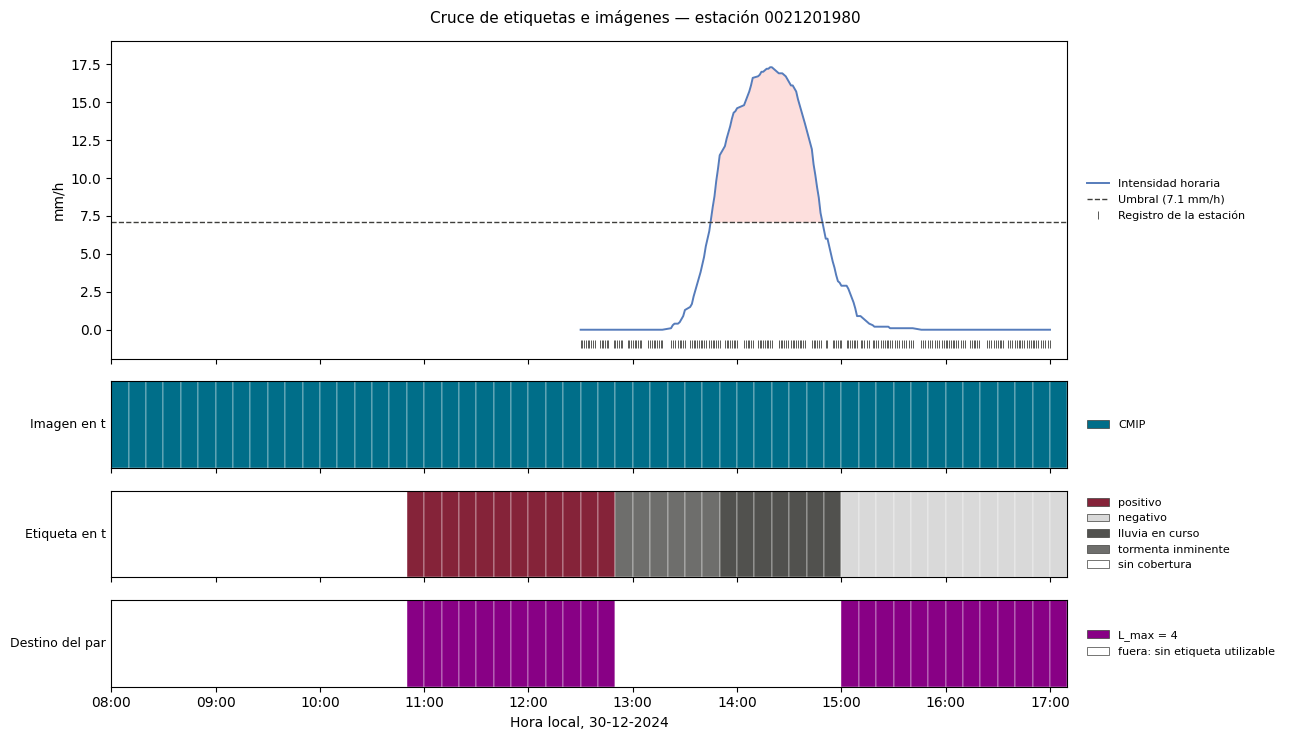

Imagen en t
estado desde hasta  n
  CMIP 08:00 17:00 55

Etiqueta en t
            estado desde hasta  n
     sin cobertura 08:00 10:40 17
          positivo 10:50 12:40 12
tormenta inminente 12:50 13:40  6
   lluvia en curso 13:50 14:50  7
          negativo 15:00 17:00 13

Destino del par
                        estado desde hasta  n
fuera: sin etiqueta utilizable 08:00 10:40 17
                     L_max = 4 10:50 12:40 12
fuera: sin etiqueta utilizable 12:50 14:50 13
                     L_max = 4 15:00 17:00 13

destino             L_max = 4  fuera: sin etiqueta utilizable
etiqueta                                                     
lluvia en curso             0                               7
negativo                   13                               0
positivo                   12                               0
sin cobertura               0                              17
tormenta inminente          0                               6


In [14]:
dia_red = etiq[(etiq["timestamp"].dt.tz_convert(TZ).dt.date == pd.Timestamp("2024-12-30").date())
               & (etiq["etiqueta"] == 1) & ~etiq["en_curso"] & etiq["sin_dato_previo"]]
print("Positivos sin dato en (t-30, t] el 30-dic-2024, por estación:")
print(dia_red.groupby("codigoestacion").size().sort_values(ascending=False).to_string(), "\n")

det_previo = figura_cruce("0021201980", "2024-12-30 08:00", "2024-12-30 17:00",
                          archivo="img-ejemplo_cruce_sin_dato_previo.png")

El 30 de diciembre de 2024 la estación 0021201980 (umbral de 7.1 mm/h) no registra datos hasta cerca de las 12:30, hora local, en un corte de transmisión que ese mismo día se observa también en otras estaciones de la red. Las imágenes de 08:00 a 10:40 quedan con etiqueta indefinida, porque el corte alcanza su ventana y la parte observada no contiene horas sobre el umbral. La de las 10:50, cuyo tramo evaluado alcanza la primera hora de lluvia fuerte, que termina a las 13:50, es positiva pese a la falta de registros en el primer bloque de su ventana. Las imágenes de 10:50 a 12:40 son positivas, las de 12:50 a 13:40 se excluyen por tormenta inminente y las de 13:50 a 14:50 por lluvia en curso.

Los positivos de 10:50 a 12:20 ilustran el límite de las exclusiones: carecen de registros en la media hora previa a $t$, de modo que no puede verificarse si la estación registraba lluvia fuerte en ese momento. La etiqueta, que depende solo de la ventana, es correcta; lo que queda sin verificar es si el par debía excluirse. Al reanudarse la transmisión, la estación registra acumulación nula durante cerca de cuarenta minutos, lo que hace muy improbable que alguno de esos positivos corresponda a una tormenta en curso.

## Sección 2 — Partición temporal

### 2.1 Períodos y corte de validación

Los pares del índice se asignan a tres períodos consecutivos, definidos en hora local: entrenamiento, del 1 de enero al 14 de noviembre de 2024; validación, del 15 de noviembre al 31 de diciembre de 2024; y prueba, el año 2025 completo. La partición es temporal y no aleatoria, puesto que los pares de instantes próximos comparten la escena y el episodio de lluvia, y una asignación aleatoria llevaría a la evaluación episodios que el modelo ya observó durante el entrenamiento. El conjunto de prueba reúne así un año completo, con sus dos temporadas de lluvia, que el modelo no ve en ninguna etapa del ajuste ni de la selección de hiperparámetros.

In [18]:
# Comparación de cortes candidatos para el inicio de la validación
CANDIDATOS = ["2024-11-01", "2024-11-15", "2024-12-01"]
MIN_EST = 5          # un día es "regional" si tiene positivos en al menos MIN_EST estaciones

p = pares[pares["etiqueta"] == 1].copy()
p["t_loc"] = p["timestamp"].dt.tz_convert(TZ)
p["dia"] = p["t_loc"].dt.date

filas = []
for c in CANDIDATOS:
    corte = pd.Timestamp(c, tz=TZ)
    tr = p[(p["t_loc"] < corte - PURGA) & (p["L_max"] >= L_MIN)]
    va = p[(p["t_loc"] >= corte) & (p["t_loc"] < CORTES["test"] - PURGA) & (p["L_max"] == L_MAX)]
    reg_tr = (tr.groupby("dia")["codigoestacion"].nunique() >= MIN_EST).sum()
    reg_va = (va.groupby("dia")["codigoestacion"].nunique() >= MIN_EST).sum()
    filas.append({"corte": c, "dias_val": (CORTES["test"] - corte).days,
                  "pos_train": len(tr), "dias_regionales_train": int(reg_tr),
                  "pos_val": len(va), "dias_con_pos_val": va["dia"].nunique(),
                  "dias_regionales_val": int(reg_va)})
print(pd.DataFrame(filas).to_string(index=False))

     corte  dias_val  pos_train  dias_regionales_train  pos_val  dias_con_pos_val  dias_regionales_val
2024-11-01        61       2488                     16     3283                38                   20
2024-11-15        47       4255                     26     1542                25                   10
2024-12-01        31       5393                     34      420                16                    2


**Corte de validación**. La fecha que separa el entrenamiento de la validación se elige comparando tres candidatos, el 1 y el 15 de noviembre y el 1 de diciembre de 2024, según los positivos de cada conjunto y los días regionales, aquellos con positivos en al menos cinco estaciones. Con el corte del 1 de diciembre, la validación conserva solo 420 positivos, repartidos en 16 días y con apenas 2 días regionales, insuficientes para seleccionar hiperparámetros con estabilidad. Con el del 1 de noviembre, la validación reúne 3,283 positivos, pero el entrenamiento se reduce a 2,488, con 16 días regionales. El corte del 15 de noviembre equilibra ambos conjuntos: el entrenamiento conserva 4,255 positivos y 26 días regionales, y la validación reúne 1,542 positivos en 25 días, 10 de ellos regionales. La comparación pone de manifiesto, además, la concentración de los eventos de 2024 en noviembre: la primera quincena del mes aporta 1,767 positivos, el 42% del conjunto de entrenamiento, de modo que el desempeño del modelo dependerá en buena medida de los episodios de esas dos semanas.

In [19]:
comp = pd.DataFrame(filas).set_index("corte")
assert comp["pos_train"].tolist() == [2488, 4255, 5393]
assert comp["pos_val"].tolist() == [3283, 1542, 420]
assert comp["dias_regionales_train"].tolist() == [16, 26, 34]
assert comp["dias_con_pos_val"].tolist() == [38, 25, 16]
assert comp["dias_regionales_val"].tolist() == [20, 10, 2]
assert f"{(4255 - 2488) / 4255:.0%}" == "42%"
print("Comparación de cortes verificada")

Comparación de cortes verificada


### 2.2 Purga

La etiqueta de un par se decide con la lluvia registrada hasta $t+3h$, de modo que, sin una precaución adicional, los pares de las últimas tres horas de cada período tendrían una etiqueta determinada por registros del período siguiente. Para evitarlo se aplica una purga: se descartan los pares cuyo instante $t$ cae en las tres horas previas a cada corte, una franja igual al horizonte de la etiqueta. Así, la ventana del último par conservado de cada período se cierra antes del corte, y ningún registro de lluvia interviene en etiquetas de dos períodos distintos. La purga separa también las imágenes de entrada, dado que la historia más larga abarca treinta minutos, bastante menos que las tres horas descartadas.

In [15]:
# ============================================================
# Sección 2 — Partición temporal con purga
# ============================================================
t_loc = indice["timestamp"].dt.tz_convert(TZ)
mascaras = {sig: ((t_loc >= c - PURGA) & (t_loc < c)).values for sig, c in CORTES.items()}

costo = pd.DataFrame({
    f"antes del corte de {sig} ({CORTES[sig]:%d-%m-%Y})": {
        "pares": int(m.sum()),
        "positivos": int((indice.loc[m, "etiqueta"] == 1).sum()),
        "estaciones": indice.loc[m, "codigoestacion"].nunique()}
    for sig, m in mascaras.items()}).T
print("Pares descartados por la purga:")
print(costo.to_string())

indice = indice[~np.logical_or.reduce(list(mascaras.values()))].reset_index(drop=True)

# Ninguna ventana de etiqueta cruza un corte y cada par queda en su período
t_loc = indice["timestamp"].dt.tz_convert(TZ)
for p, sig in [("train", "val"), ("val", "test")]:
    en_p = (indice["periodo"] == p).values
    assert (t_loc[en_p] + PURGA < CORTES[sig]).all(), f"ventana de {p} cruza el corte de {sig}"
assert (t_loc[(indice["periodo"] == "val").values] >= CORTES["val"]).all()
assert (t_loc[(indice["periodo"] == "test").values] >= CORTES["test"]).all()

Pares descartados por la purga:
                                      pares  positivos  estaciones
antes del corte de val (15-11-2024)    1051          4          61
antes del corte de test (01-01-2025)    756          0          61


In [17]:
def dias_sin_pares(periodo, ini, fin):
    todos = pd.date_range(ini, fin, freq="D")
    con = pd.to_datetime(pd.Series(indice.loc[indice["periodo"] == periodo, "timestamp"]
                                   .dt.tz_convert(TZ).dt.date.unique()))
    sin = todos[~todos.isin(con)]
    if len(sin) == 0:
        return pd.DataFrame()
    g = (pd.Series(sin).diff() != pd.Timedelta("1D")).cumsum().values
    return pd.DataFrame({"dia": sin}).groupby(g)["dia"].agg(desde="min", hasta="max", dias="size").reset_index(drop=True)

print("Entrenamiento:\n", dias_sin_pares("train", "2024-01-01", "2024-11-14").to_string(index=False))
print("\nPrueba:\n", dias_sin_pares("test", "2025-01-01", "2025-12-31").to_string(index=False))

Entrenamiento:
      desde      hasta  dias
2024-01-07 2024-01-07     1
2024-01-09 2024-01-09     1
2024-01-12 2024-01-12     1
2024-01-19 2024-01-21     3
2024-02-16 2024-02-19     4
2024-03-08 2024-03-08     1
2024-04-25 2024-04-28     4
2024-05-03 2024-05-03     1
2024-06-01 2024-06-21    21
2024-06-23 2024-06-23     1
2024-07-26 2024-08-01     7
2024-09-19 2024-09-23     5
2024-10-22 2024-10-25     4

Prueba:
      desde      hasta  dias
2025-02-05 2025-02-24    20
2025-05-22 2025-05-23     2


Los períodos no cubren todos los días del calendario: 54 de los 319 días del período de entrenamiento y 22 de los 365 del de prueba carecen de pares utilizables en todas las estaciones, lo que indica cortes que afectan simultáneamente a toda la red. Los tramos más largos caen fuera de las temporadas de lluvia, del 1 al 21 de junio de 2024 y del 5 al 24 de febrero de 2025, mientras que en el entrenamiento las temporadas de marzo a mayo y de septiembre a noviembre pierden 6 y 9 días, respectivamente, de modo que los cortes no reducen de forma apreciable la representación de los meses más lluviosos. La validación cubre sus 47 días.

In [16]:
# Conjuntos efectivos de cada modelo: entrenamiento con L_max ≥ L; validación y prueba con L_max = 4
filas = []
for p in ORDEN:
    d = indice[indice["periodo"] == p]
    for L in ((2, 3, 4) if p == "train" else (4,)):
        s_ = d[d["L_max"] >= L]
        n_pos_ = int((s_["etiqueta"] == 1).sum())
        filas.append({"periodo": p, "uso": f"L_max ≥ {L}",
                      "dias": s_["timestamp"].dt.tz_convert(TZ).dt.date.nunique(),
                      "pares": len(s_), "positivos": n_pos_,
                      "prevalencia": f"{n_pos_ / len(s_):.3%}",
                      "neg_por_pos": round((len(s_) - n_pos_) / n_pos_)})
conjuntos = pd.DataFrame(filas)
print(conjuntos.to_string(index=False))

print("\nComposición por satélite y origen de la imagen de t:")
print(pd.crosstab(indice["periodo"], [indice["satelite"], indice["origen"]]).reindex(ORDEN).to_string())

RUTA_INDICE.parent.mkdir(exist_ok=True)
indice.to_parquet(RUTA_INDICE, index=False)
print(f"\nGuardado: {RUTA_INDICE.name}  |  {len(indice):,} pares, "
      f"{int((indice['etiqueta'] == 1).sum()):,} positivos  |  columnas: {list(indice.columns)}")

periodo       uso  dias   pares  positivos prevalencia  neg_por_pos
  train L_max ≥ 2   265 1247317       4255      0.341%          292
  train L_max ≥ 3   265 1244575       4208      0.338%          295
  train L_max ≥ 4   265 1241973       4161      0.335%          297
    val L_max ≥ 4    47  331916       1542      0.465%          214
   test L_max ≥ 4   343 2442338      12367      0.506%          196

Composición por satélite y origen de la imagen de t:
satelite      G16            G19
origen       CMIP   L1b     CMIP
periodo                         
train     1243515  3802        0
val        333233     0        0
test       513173     0  1936202

Guardado: indice_completo.parquet  |  4,029,925 pares, 18,229 positivos  |  columnas: ['codigoestacion', 'timestamp', 'etiqueta', 'L_max', 'periodo', 'satelite', 'origen', 'filepath', 'fila', 'col']


**Resultado**. La purga descarta 1,051 pares antes del corte de validación y 756 antes del de prueba, que contienen 4 positivos y ninguno, respectivamente. El índice final reúne 4,029,925 pares con 18,229 positivos. El modelo con $L = 2$ se entrena con 1,247,317 pares y 4,255 positivos, y el modelo con $L = 4$ con 1,241,973 pares y 4,161 positivos; el conjunto común de validación reúne 331,916 pares con 1,542 positivos, y el de prueba, 2,442,338 pares con 12,367 positivos. La prevalencia crece de un período al siguiente, de 0.341% en entrenamiento a 0.465% en validación y 0.506% en prueba, y con ella baja el desbalance, de 292 a 214 y 196 negativos por cada positivo, en coherencia con la menor prevalencia de 2024 descrita en 05-ground_truth_labels.ipynb. Los instantes reconstruidos desde L1b aportan 3,802 pares, todos en entrenamiento, y el conjunto de prueba combina imágenes de GOES-16, hasta el 4 de abril de 2025, con imágenes de GOES-19, que aportan el 79% de sus pares.

Los períodos no cubren todos los días del calendario: 54 de los 319 días del período de entrenamiento y 22 de los 365 del de prueba carecen de pares utilizables en todas las estaciones, lo que indica cortes que afectan simultáneamente a toda la red. Los tramos más largos caen fuera de las temporadas de lluvia, del 1 al 21 de junio de 2024 y del 5 al 24 de febrero de 2025, mientras que en el entrenamiento las temporadas de marzo a mayo y de septiembre a noviembre pierden 6 y 9 días, respectivamente, de modo que los cortes no reducen de forma apreciable la representación de los meses más lluviosos. La validación cubre sus 47 días.

In [20]:
# Cifras citadas en el texto de la Sección 2.3
assert costo["pares"].tolist() == [1051, 756] and costo["positivos"].tolist() == [4, 0]
assert (len(indice), int((indice["etiqueta"] == 1).sum())) == (4_029_925, 18_229)
assert conjuntos["pares"].tolist() == [1_247_317, 1_244_575, 1_241_973, 331_916, 2_442_338]
assert conjuntos["positivos"].tolist() == [4255, 4208, 4161, 1542, 12367]
assert conjuntos["neg_por_pos"].tolist() == [292, 295, 297, 214, 196]
assert conjuntos["dias"].tolist() == [265, 265, 265, 47, 343]
assert int((indice["origen"] == "L1b").sum()) == 3802
assert f"{(indice.loc[indice['periodo'] == 'test', 'satelite'] == 'G19').mean():.0%}" == "79%"
assert dias_sin_pares("train", "2024-01-01", "2024-11-14")["dias"].sum() == 54
assert dias_sin_pares("test", "2025-01-01", "2025-12-31")["dias"].sum() == 22
print("Cifras de la Sección 2 verificadas")

Cifras de la Sección 2 verificadas


In [22]:
indice.head(3)

,codigoestacion,timestamp,etiqueta,L_max,periodo,satelite,origen,filepath,fila,col
0,0021201980,2024-01-05 18:10:00+00:00,0.0,4,train,G16,CMIP,C:\Users\diani\Documents\repositories\nowcasti...,99,101
1,0021201980,2024-01-05 18:20:00+00:00,0.0,4,train,G16,CMIP,C:\Users\diani\Documents\repositories\nowcasti...,99,101
2,0021201980,2024-01-05 18:30:00+00:00,0.0,4,train,G16,CMIP,C:\Users\diani\Documents\repositories\nowcasti...,99,101


## Sección 3 — Negativos de entrenamiento

El desbalance del conjunto no se corrige en el índice. Su compensación recae sobre la función de pérdida, y la proporción entre positivos y negativos con que se muestrea el entrenamiento es un hiperparámetro que se determina en las notebooks de modelado. La validación y la prueba conservan su prevalencia real. Esta sección prepara el índice para ese muestreo: clasifica los negativos en dos grupos y agrega las columnas que permiten variar el criterio sin reconstruir el índice.

Fan et al. (2024) distinguen dos tipos de casos negativos: los near-miss, recortes vecinos a un evento que no contienen uno propio, y los aleatorios, extraídos del resto del dominio. Los near-miss comparten con los positivos el contexto convectivo de la escena y son, por tanto, los más informativos para delimitar la frontera de decisión. En un diseño por estación, el análogo del recorte vecino es una estación cercana a otra que registra un evento en el mismo instante. El vecindario no se toma del tamaño de recorte de Fan et al. (48 km), elegido para su dominio y para plazos de hasta una hora, sino que se determina a partir de la co-ocurrencia de positivos entre las estaciones de la red durante el período de entrenamiento.

In [25]:
KM_PX = 2.0                                     # resolución nominal del píxel GOES sobre la Sabana

# Distancias entre estaciones a partir de su píxel en la grilla GOES
px = pixels.assign(codigoestacion=pixels["codigoestacion"].astype(str).str.zfill(10)).set_index("codigoestacion")
P  = px[["fila", "col"]].to_numpy(float)
D  = np.sqrt(((P[:, None, :] - P[None, :, :]) ** 2).sum(-1)) * KM_PX
iu = np.triu_indices(len(P), 1)
dist_est = pd.Series(D[iu])
print("Distancia entre estaciones (km):")
print(dist_est.describe(percentiles=[.25, .5, .75, .9]).round(1).to_string())

# Co-ocurrencia de positivos en el mismo t (solo entrenamiento), agregada por tramo de distancia
tr  = pares[pares["periodo"] == "train"]
W   = tr.pivot(index="timestamp", columns="codigoestacion", values="etiqueta").reindex(columns=px.index)
pos_m, val_m = (W == 1).to_numpy(float), W.notna().to_numpy(float)
with np.errstate(divide="ignore", invalid="ignore"):
    prev = pos_m.sum(0) / val_m.sum(0)
ambos, a_pos = pos_m.T @ pos_m, pos_m.T @ val_m
fuera = ~np.eye(len(P), dtype=bool)
co = pd.DataFrame({"dist_km": D[fuera], "ambos": ambos[fuera], "a_pos": a_pos[fuera],
                   "prev_b": np.broadcast_to(prev, D.shape)[fuera]}).dropna()
co["tramo"] = pd.cut(co["dist_km"], bins=[0, 5, 10, 15, 20, 25, 30, 40, 64], include_lowest=True)
g = co.groupby("tramo", observed=True)
coocur = pd.DataFrame({"pares": g.size() // 2,
                       "p_cond": g["ambos"].sum() / g["a_pos"].sum()})
coocur["lift"] = coocur["p_cond"] / ((co["a_pos"] * co["prev_b"]).groupby(co["tramo"], observed=True).sum()
                                     / g["a_pos"].sum())
print("\nCo-ocurrencia de positivos por distancia (entrenamiento):")
print(coocur.round(3).to_string())

mismo_px = [(px.index[i], px.index[j]) for i, j in zip(*iu) if D[i, j] == 0]
sin_pos  = px.index[pos_m.sum(0) == 0].tolist()
print(f"\nPares de estaciones en el mismo píxel: {len(mismo_px)}")
print(f"Estaciones sin positivos en entrenamiento: {sin_pos}")

Distancia entre estaciones (km):
count    1953.0
mean       15.8
std        10.0
min         0.0
25%         8.2
50%        13.4
75%        21.3
90%        28.6
max        57.7

Co-ocurrencia de positivos por distancia (entrenamiento):
               pares  p_cond     lift
tramo                                
(-0.001, 5.0]    212   0.376  101.328
(5.0, 10.0]      432   0.175   44.313
(10.0, 15.0]     428   0.087   21.545
(15.0, 20.0]     298   0.071   16.324
(20.0, 25.0]     229   0.068   17.283
(25.0, 30.0]     153   0.056   13.220
(30.0, 40.0]     110   0.024    3.484
(40.0, 64.0]      59   0.094   10.782

Pares de estaciones en el mismo píxel: 7
Estaciones sin positivos en entrenamiento: ['0021205420', '2120000136']


**Escala espacial de los eventos**. Las 63 estaciones se encuentran a una distancia mediana de 13.4 km entre sí, con un máximo de 57.7 km, de modo que todas caben dentro de un parche de entrada. La probabilidad de que una estación registre un positivo cuando otra lo registra en el mismo instante decae rápidamente en los primeros kilómetros, de 101 veces su prevalencia a menos de 5 km a unas 22 veces entre 10 y 15 km, y se estabiliza después entre 13 y 17 veces hasta los 30 km; aun entre 30 y 40 km se mantiene 3.5 veces por encima de la prevalencia. La caída inicial refleja la escala de la celda convectiva, y la meseta, el alcance regional de las tardes convectivas de la Sabana, en las que varias estaciones registran lluvia fuerte en las mismas horas. Dado que en ningún tramo de distancias dentro de la red la co-ocurrencia desciende al nivel esperado por azar, el vecindario se define como la red completa: un negativo es near-miss si, en el mismo instante $t$, al menos otra estación tiene etiqueta positiva. Los demás negativos conforman el grupo aleatorio.

Siete pares de estaciones comparten el píxel GOES, de modo que sus parches de entrada son idénticos. Cuando una tiene etiqueta positiva y la otra negativa en el mismo instante, el conjunto contiene dos ejemplos con la misma entrada y etiquetas opuestas, reflejo de que la lluvia registrada por un pluviómetro varía a escalas menores que el píxel. Dos estaciones, 2120000136 y 0021205420, no registran positivos en el período de entrenamiento.

In [27]:
# Positivos de referencia: todos los utilizables de 05 (con o sin imagen), el evento ocurrió igual
est_idx = {c: i for i, c in enumerate(px.index)}
pos_ref = pares.loc[pares["etiqueta"] == 1, ["timestamp", "codigoestacion", "periodo"]]

# n_est_pos: otras estaciones con positivo en el mismo t
cnt = pos_ref.groupby("timestamp").size()
indice["n_est_pos"] = (indice["timestamp"].map(cnt).fillna(0).astype(int)
                       - (indice["etiqueta"] == 1).astype(int))

# dist_pos_km: distancia a la estación positiva más cercana en el mismo t (sin contar la propia)
pos_por_t = pos_ref.groupby("timestamp")["codigoestacion"].apply(lambda s: np.array([est_idx[c] for c in s]))
dist = np.full(len(indice), np.nan)
sub = indice[indice["timestamp"].isin(pos_por_t.index)]
for t, gt in sub.groupby("timestamp"):
    pe = pos_por_t[t]
    ei = gt["codigoestacion"].map(est_idx).to_numpy()
    Dm = D[np.ix_(ei, pe)].copy()
    Dm[ei[:, None] == pe[None, :]] = np.inf
    d = Dm.min(axis=1)
    dist[gt.index] = np.where(np.isinf(d), np.nan, d)
indice["dist_pos_km"] = dist

# horas_a_positivo: horas al positivo más cercano de la misma estación, dentro del mismo período (solo negativos)
pos_sp = pos_ref.groupby(["codigoestacion", "periodo"])["timestamp"].apply(
    lambda s: np.sort(s.dt.tz_convert(None).to_numpy("datetime64[ns]")))
horas = np.full(len(indice), np.nan)
neg_idx = indice.index[indice["etiqueta"] == 0]
for (cod, per), gn in indice.loc[neg_idx].groupby(["codigoestacion", "periodo"]):
    if (cod, per) not in pos_sp.index:
        continue
    tp, tg = pos_sp[(cod, per)], gn["timestamp"].dt.tz_convert(None).to_numpy("datetime64[ns]")
    i = np.searchsorted(tp, tg)
    izq, der = tp[np.clip(i - 1, 0, len(tp) - 1)], tp[np.clip(i, 0, len(tp) - 1)]
    horas[gn.index] = np.minimum(np.abs(tg - izq), np.abs(tg - der)) / np.timedelta64(1, "h")
indice["horas_a_positivo"] = horas

indice["pool"] = np.select([indice["etiqueta"] == 1,
                            (indice["etiqueta"] == 0) & (indice["n_est_pos"] >= 1)],
                           ["positivo", "near_miss"], "aleatorio")
print(indice[["n_est_pos", "dist_pos_km", "horas_a_positivo"]].describe().round(2).to_string())

        n_est_pos  dist_pos_km  horas_a_positivo
count  4029925.00    311403.00        3987095.00
mean         0.25        15.03            551.88
std          1.37        11.26            754.79
min          0.00         0.00              0.17
25%          0.00         6.32             86.67
50%          0.00        12.17            280.17
75%          0.00        20.40            746.00
max         38.00        57.72           6780.83


In [28]:
VENTANA_H = 24          # criterio temporal alternativo (horas)

filas = []
for L in (2, 4):
    d = indice[(indice["periodo"] == "train") & (indice["L_max"] >= L)]
    n_pos_ = int((d["pool"] == "positivo").sum())
    for pool in ["near_miss", "aleatorio"]:
        n = int((d["pool"] == pool).sum())
        filas.append({"L_max ≥": L, "pool": pool, "pares": n, "por_positivo": round(n / n_pos_, 1)})
pools = pd.DataFrame(filas)
print("Grupos de negativos en entrenamiento:")
print(pools.to_string(index=False))

neg_tr = indice[(indice["periodo"] == "train") & (indice["etiqueta"] == 0)]
print(f"\nCriterio espacial (near-miss) frente al temporal (±{VENTANA_H} h):")
print(pd.crosstab(neg_tr["pool"], neg_tr["horas_a_positivo"] <= VENTANA_H,
                  margins=True).rename(columns={True: f"≤ {VENTANA_H} h", False: f"> {VENTANA_H} h"}).to_string())

nm = neg_tr[neg_tr["pool"] == "near_miss"]
print(f"\nNear-miss a 0 km (estación que comparte píxel con una positiva): {int((nm['dist_pos_km'] == 0).sum()):,}")
print("Distancia a la positiva más cercana en los near-miss (km):")
print(nm["dist_pos_km"].describe(percentiles=[.25, .5, .75]).round(1).to_string())

RUTA_INDICE.parent.mkdir(exist_ok=True)
indice.to_parquet(RUTA_INDICE, index=False)
print(f"\nGuardado: {RUTA_INDICE.name}  |  {len(indice):,} pares  |  columnas: {list(indice.columns)}")

Grupos de negativos en entrenamiento:
 L_max ≥      pool   pares  por_positivo
       2 near_miss   56788          13.3
       2 aleatorio 1186274         278.8
       4 near_miss   56110          13.5
       4 aleatorio 1181702         284.0

Criterio espacial (near-miss) frente al temporal (±24 h):
horas_a_positivo   > 24 h  ≤ 24 h      All
pool                                      
aleatorio         1111830   74444  1186274
near_miss           43320   13468    56788
All               1155150   87912  1243062

Near-miss a 0 km (estación que comparte píxel con una positiva): 333
Distancia a la positiva más cercana en los near-miss (km):
count    56788.0
mean        13.5
std          9.4
min          0.0
25%          6.3
50%         11.3
75%         18.1
max         57.7

Guardado: indice_completo.parquet  |  4,029,925 pares  |  columnas: ['codigoestacion', 'timestamp', 'etiqueta', 'L_max', 'periodo', 'satelite', 'origen', 'filepath', 'fila', 'col', 'n_est_pos', 'dist_pos_km', 'horas_a

**Resultado.** En el conjunto de entrenamiento con la historia mínima ($L_{max} \geq 2$), 56,788 negativos son near-miss, 13.3 por cada positivo, y 1,186,274 forman el grupo aleatorio, 278.8 por positivo; con la historia completa las proporciones son prácticamente iguales (13.5 y 284.0). La distancia mediana entre un near-miss y la estación positiva más cercana es de 11.3 km, dentro de la escala en que la co-ocurrencia de positivos es más intensa. Solo 333 near-miss (0.6%) corresponden a estaciones que comparten el píxel con una estación positiva, de modo que los pares con entrada idéntica y etiquetas opuestas son una fracción menor del grupo.

Los criterios espacial y temporal seleccionan negativos en buena medida distintos. De los 56,788 near-miss, 13,468 (24%) se encuentran además a menos de 24 horas de un positivo de la misma estación, mientras que el criterio temporal reúne otros 74,444 negativos en instantes en que ninguna estación de la red registra un evento. Ambos criterios se conservan en el índice (`dist_pos_km`, `n_est_pos` y `horas_a_positivo`), de modo que el criterio de selección puede compararse empíricamente durante el modelado.

In [29]:
indice.head(3)

,codigoestacion,timestamp,etiqueta,L_max,periodo,satelite,origen,filepath,fila,col,n_est_pos,dist_pos_km,horas_a_positivo,pool
0,0021201980,2024-01-05 18:10:00+00:00,0.0,4,train,G16,CMIP,C:\Users\diani\Documents\repositories\nowcasti...,99,101,0,NaN,675.000000,aleatorio
1,0021201980,2024-01-05 18:20:00+00:00,0.0,4,train,G16,CMIP,C:\Users\diani\Documents\repositories\nowcasti...,99,101,0,NaN,674.833333,aleatorio
2,0021201980,2024-01-05 18:30:00+00:00,0.0,4,train,G16,CMIP,C:\Users\diani\Documents\repositories\nowcasti...,99,101,0,NaN,674.666667,aleatorio


In [30]:
# Cifras citadas: escala espacial
assert (round(dist_est.median(), 1), round(dist_est.max(), 1)) == (13.4, 57.7)
assert coocur["lift"].round(1).tolist() == [101.3, 44.3, 21.5, 16.3, 17.3, 13.2, 3.5, 10.8]
assert len(mismo_px) == 7 and sorted(sin_pos) == ["0021205420", "2120000136"]
print("Cifras de la escala espacial verificadas")

Cifras de la escala espacial verificadas


In [31]:
# Cifras citadas: grupos de negativos
assert pools["pares"].tolist() == [56_788, 1_186_274, 56_110, 1_181_702]
assert pools["por_positivo"].tolist() == [13.3, 278.8, 13.5, 284.0]
ct = pd.crosstab(neg_tr["pool"], neg_tr["horas_a_positivo"] <= VENTANA_H)
assert (ct.loc["near_miss", True], ct.loc["aleatorio", True]) == (13_468, 74_444)
assert int((nm["dist_pos_km"] == 0).sum()) == 333 and round(nm["dist_pos_km"].median(), 1) == 11.3
print("Cifras de los grupos de negativos verificadas")

Cifras de los grupos de negativos verificadas
